# Partie 1 - Recherche, compréhension et préparation des données

In [1]:
# Importations des librairies nécessaires
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization,Activation,AveragePooling2D,Dropout
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

## 1. Description et importation du dataset :

- **Source**: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset/data
- **Nom** : RAF-DB
- **Auteurs** : Shan Li, Weihong Deng, distribué sur Kaggle par l'utilisateur "Dev-ShuvoAlok"
- **Nombre total d'images dans la distribution Kaggle** : 15339
- **Dimensions des images** : 100px x 100px
- **Format** : couleur, .jpg

---


| ID      | Classes   | Effectif  |
| :------ | :-------- | :-------- |
| 1       | Surprise  | 1 619     |
| 2       | Peur      | 355       |
| 3       | Dégoût    | 877       |
| 4       | Joie      | 5 957     |
| 5       | Tristesse | 2 460     |
| 6       | Colère    | 867       |
| 7       | Neutre    | 3 204     |
| Total   |           | 15 339    |

Note : Il y a un fort déséquilibre entre les classes.

---



## 2. Téléchargement du dataset (nécessite un token sur Kaggle)

**Important :** Il faut aller dans "Secrets" sur la barre latérale gauche du Google Colab et créer les variables : `KAGGLE_USERNAME` et `KAGGLE_KEY`, en activant "Accès depuis le notebook". Remplir leurs valeurs avec le nom d'un compte Kaggle et le token (obtenu sur Kaggle dans "Your API tokens" et "Generate New Token")

In [ ]:
import os
from google.colab import userdata

# Installation de l'API Kaggle pour importer le dataset
!pip install -U -q kaggle

# 2. Injection des variables d'environnement secrètes
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

# 3. Téléchargement direct et extraction du dataset
!kaggle datasets download -d shuvoalok/raf-db-dataset --force
!unzip -q -o raf-db-dataset.zip -d ./raf_db

print("Dataset RAF-DB téléchargé et extrait avec succès via Kaggle API.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.5 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
100% 37.7M/37.7M [00:00<00:00, 52.6MB/s]

Dataset RAF-DB téléchargé et extrait avec succès via Kaggle API.


## 3. Préparation des données

- Normalisation des pixels en divisant par 255 pour qu'ils soient entre $[0,1]$.
- Modification des labels pour commener à l'ID 0.
- Constitution des ensembles **train / validation / test** avec la répartition suivante : **80% train, 10% validation, 10% test.**

In [ ]:
import os, glob
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Chemin du dataset extrait
BASE_DIR = './raf_db/DATASET'

# Fixer la graine d'aléatoire pour que le notebook soit reproductible
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Construction du DataFrame en scannant les dossiers (label = nom du dossier)
def scan_split(split):
    rows = []
    for cls in range(1, 8):
        folder = os.path.join(BASE_DIR, split, str(cls))
        for p in glob.glob(os.path.join(folder, "*")):
            if p.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append({"image_path": p, "label": cls - 1})  # 1..7 -> 0..6
    return pd.DataFrame(rows)

df_train = scan_split("train")
df_test_full = scan_split("test")

# Vérification
assert len(df_train) > 0, "Aucune image trouvée : vérifier BASE_DIR"

# Split validation (50 % du set de test)
df_test, df_val = train_test_split(
    df_test_full,
    test_size=0.5,
    random_state=SEED,
    stratify=df_test_full["label"],
)

print(f"Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}")

# 5. Pipeline tf.data
IMG_SIZE = 100 # garde la dimension originelle des images du dataset qui est 100x100
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE))
    image = image / 255.0
    return image, label

def build_tf_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["image_path"].values, dataframe["label"].values)
    )
    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_dataset = build_tf_dataset(df_train, shuffle=True)
val_dataset = build_tf_dataset(df_val, shuffle=False)
test_dataset = build_tf_dataset(df_test, shuffle=False)

print("Distribution train :\n", df_train["label"].value_counts().sort_index())
print("Distribution val  :\n", df_val["label"].value_counts().sort_index())
print("Distribution test  :\n", df_test["label"].value_counts().sort_index())

Train : 12271 | Val : 1534 | Test : 1534
Distribution train :
 label
0    1290
1     281
2     717
3    4772
4    1982
5     705
6    2524
Name: count, dtype: int64
Distribution val  :
 label
0    165
1     37
2     80
3    592
4    239
5     81
6    340
Name: count, dtype: int64
Distribution test  :
 label
0    164
1     37
2     80
3    593
4    239
5     81
6    340
Name: count, dtype: int64


### Résumé des répartitions

| ID de la classe |      Train | Validation |      Test |      Total |
| --------------: | ---------: | ---------: | --------: | ---------: |
|               0 |      1 290 |        165 |       164 |  **1 619** |
|               1 |        281 |         37 |        37 |    **355** |
|               2 |        717 |         80 |        80 |    **877** |
|               3 |      4 772 |        592 |       593 |  **5 957** |
|               4 |      1 982 |        239 |       239 |  **2 460** |
|               5 |        705 |         81 |        81 |    **867** |
|               6 |      2 524 |        340 |       340 |  **3 204** |
|       **Total** | **12 271** |  **1 534** | **1 534** | **15 339** |

---

### Visualisation du dataset

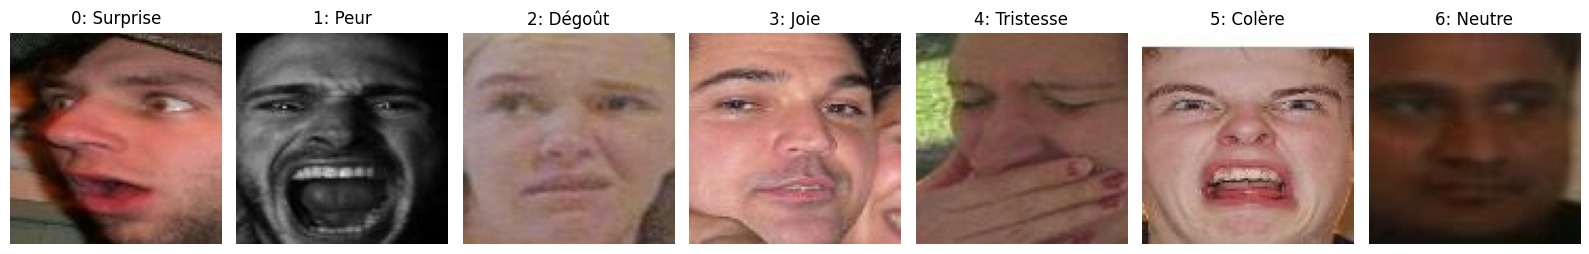

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

emotions = ["Surprise", "Peur", "Dégoût", "Joie", "Tristesse", "Colère", "Neutre"]

fig, axes = plt.subplots(1, 7, figsize=(16, 3))
for label, ax in enumerate(axes):
    row = df_train[df_train["label"] == label].sample(1, random_state=SEED).iloc[0]
    ax.imshow(Image.open(row["image_path"]))
    ax.set_title(f"{label}: {emotions[label]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Partie 2 - Construction d'un modèle de référence

## 1. Explications

Le but est ici de constuire un modèle qui servira de référence et qui ne sera donc selon la logique du problème donné, peu adapté et donnera des résultats qui seront battus par le CNN, dans la partie 3.

Le modèle sera alors constitiué de :

- La couche d'entrée contenant l'image
- Une couche flatten transformant l'image en une représentation vectorielle à 30 000 valeurs
- Une couche dense à 128 neurones + activation ReLU
- Une deuxième couche dense à 7 neurones + activation Softmax (une sortie par classe = expression du visage).

Pour l'entraînement, nous utilisons l'optimizer Adam (learning rate de $0.001$), la fonction de coût sparse categorical cross entropy (adaptée à des labels encodés sous forme d'entiers de 0 à 6), et, à la fin de chaque époque, nous calculons l'accuracy et le coût pour l'entraînement et la validation.

(Plus de détails sur les paramètres d'entraînement dans la Partie 4, ce sont les mêmes réutilisés).

## 2. Tableau des dimensions et paramètres

| Étape / Séquence | Type de Couche | Paramètres / Nombre de neurones | Dimensions d'entrée (Shape) | Dimensions de sortie (Shape) |
| :--- | :--- | :--- | :--- | :--- |
| **1. Image** | Input | - | `(None, 100, 100, 3)` | `(None, 100, 100, 3)` |
| **2. Flatten** | Flatten | - | `(None, 100, 100, 3)` | `(None, 30 000)` |
| **3. Dense + activation** | Dense | 128 neurones *(modifiable)* | `(None, 30 000)` | `(None, 128)` |
| | Activation | ReLU | `(None, 128)` | `(None, 128)` |
| **4. Dense** | Dense | 7 neurones (classes de sortie) | `(None, 128)` | `(None, 7)` |
| **5. Softmax** | Activation / Softmax | - | `(None, 7)` | `(None, 7)` |

In [ ]:
model_ref = Sequential()

model_ref.add(Flatten(input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_ref.add(Dense(128, activation="relu"))
model_ref.add(Dense(7))
model_ref.add(Activation("softmax"))

model_ref.summary()



/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841,031 (14.65 MB)

 Trainable params: 3,841,031 (14.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_ref.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # les labels sont des entiers de 0 à 6, pas one-hot enconding donc sparse
    metrics=["accuracy"],
)

# Class weight car classes déséquilibrés : appliquer des multiplicateurs par classe sur la loss pour que les
# erreurs sur les classes rares coûtent plus que les erreurs sur les classes communes
classes = np.arange(7)
w = compute_class_weight("balanced", classes=classes, y=df_train["label"].values)
class_weight = dict(zip(classes, w))

class MacroF1(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, y_pred, average="macro")


EPOCHS = 30
callbacks = [
    MacroF1(val_dataset, df_val["label"].values), # important à laisser en premier pour que val_macro_f1 soit déjà dans les logs quand ReduceLrOnPlateau et Early stopping le lisent
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
]

history_ref = model_ref.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,class_weight=class_weight, callbacks=callbacks)


Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1311 - loss: 2.9653 - val_accuracy: 0.0241 - val_loss: 1.9400 - val_macro_f1: 0.0067 - learning_rate: 0.0010
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.2301 - loss: 1.9018 - val_accuracy: 0.3768 - val_loss: 1.9373 - val_macro_f1: 0.1068 - learning_rate: 0.0010
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3763 - loss: 1.8748 - val_accuracy: 0.3292 - val_loss: 1.9847 - val_macro_f1: 0.1013 - learning_rate: 0.0010
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1984 - loss: 1.8640 - val_accuracy: 0.3729 - val_loss: 1.9176 - val_macro_f1: 0.1156 - learning_rate: 0.0010
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.2754 - loss: 1.8463 - val_accuracy: 0.4113 - val_loss: 1.6976 - val_macro_f1: 0.2000 - learning_rate: 0.0010
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3972 - loss: 1.7577 - val_accuracy: 0.3220 - val_loss

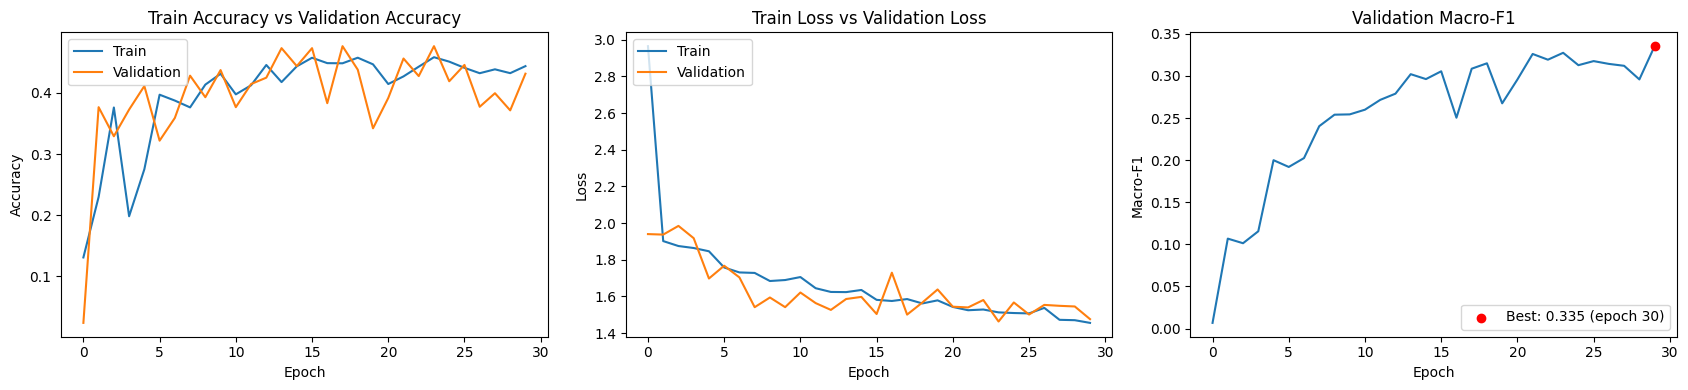

In [ ]:
# Tracé des courbes de loss, d'accuracy et macro-f1

fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(history_ref.history['accuracy'])
ax[0].plot(history_ref.history['val_accuracy'])
ax[0].set_title('Train Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history_ref.history['loss'])
ax[1].plot(history_ref.history['val_loss'])
ax[1].set_title('Train Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

f1 = history_ref.history['val_macro_f1']
best = int(np.argmax(f1))
ax[2].plot(f1)
ax[2].scatter(best, f1[best], color="red", zorder=3, label=f"Best: {f1[best]:.3f} (epoch {best + 1})")
ax[2].set_title('Validation Macro-F1')
ax[2].set_ylabel('Macro-F1')
ax[2].set_xlabel('Epoch')
ax[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

### (Optionel) charger le modèle dense pré-entraîné (fourni dans le dépôt Git)
Pour éviter de devoir réentraîner exécutant la cellule d'entraînement, exécuter cette cellule :

In [ ]:
model_ref = keras.models.load_model("models/mlp_baseline.keras")

# Partie 3 - Construction d'un CNN avec Keras

## 1. Explications

* **Filtres** : chaque filtre est une petite matrice de poids apprise qui détecte un motif précis (bord, texture, puis partie du visage). Choix **32 -> 64 -> 128** : peu de filtres suffisent pour détecter les motifs simples des premières couches, puis davantage pour détecter les motifs abstraits des couches profondes. Aussi, le pooling applique divise la résolution spatiale par 2 dans chaque dimension, donc pour garder un coût de calcul par couche à peu près constant par couche, on double les canaux.

* **Convolution** : on fait glisser le filtre sur toute l'image et on calcule un produit scalaire à chaque position. Les poids sont partagés sur toute l'image, ce qui réduit fortement le nombre de paramètres par rapport à une couche dense et donne une détection indépendante de la position du motif.

* **Feature maps** : sortie d'un filtre appliqué à toute l'entrée. Une couche à 32 filtres produit 32 feature maps empilées en canaux.

* **Kernel 3×3**: petit noyau peu coûteux (9 poids par canal), un choix standard depuis l'architecture VGG qui prouve qu'empiler des couches de petits kernels agrandit le champ réceptif et ajoute de la non-linéarité (deux kernels 3×3 équivaut à un kernel 5×5 mais avec moins de paramètres).

* **Stride (1)** : pas de déplacement du filtre. Stride 1 garde toute l'information spatiale. La réduction de résolution est déléguée au pooling.

* **`padding = "same"`** : ajoute des zéros pour conserver la taille spatiale en sortie de convolution. Les pixels de bord contribuent autant que les autres, et seul le pooling réduit la résolution, ce qui rend les dimensions prévisibles.

* **ReLU** : $max(0, x)$. Elle apporte la non-linéarité, est très peu coûteuse et limite le problème de gradient qui s'annule, contrairement à sigmoïde/tanh.

* **BatchNormalization** : normalise les activations par batch. Elle stabilise et accélère l'entraînement, et autorise `use_bias=False` (le biais est redondant avec le beta de batch normalization).

* **MaxPooling 2×2** : garde la valeur maximale de chaque fenêtre 2×2, divise la résolution spatiale par 2, réduit le calcul et apporte une tolérance aux petites translations.

* **Flatten** : transforme le volume 3D ($H \times W \times C$) en vecteur 1D pour le brancher sur une couche dense.

* **Couches Dense** : chaque neurone reçoit toutes les entrées, ce qui combine les features extraites pour décider.

* **Couche de sortie** : Dense(7, softmax) car 7 classes, et softmax transforme les scores en probabilités qui somment à 1, adapté à la classification multi-classe à une seule étiquette par image.

## 2. Tableau des dimensions et paramètres

| Couche                 | Dimension sortie | Explications                                                                                                                                                                                                                 |
| ---------------------- | ---------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Entrée**             | `(100, 100, 3)`  | Les images d’entrée sont de forme 100px x 100px et 3 canaux (RGB).                                                                                                               |
| **Conv2D (32)**        | `(100, 100, 32)` | Il y a 32 filtres de taille `3x3`. Comme `padding="same"` et que le stride vaut 1 par défaut, la hauteur et la largeur restent 100x100. Chaque filtre produit une feature map, d’où les 32 canaux. |
| **BatchNormalization** | `(100, 100, 32)` | La normalisation par lot ne modifie pas les dimensions. Elle normalise les activations des 32 canaux.                                                                                                                    |
| **ReLU**               | `(100, 100, 32)` | La fonction d’activation ReLU est appliquée élément par élément (ne change pas la dimension).                                                                                                                       |
| **MaxPooling2D**       | `(50, 50, 32)`   | Le `pool_size=(2,2)` réduit de moitié la hauteur et la largeur : `100/2 = 50`. Le nombre de canaux reste 32.                                                                                                             |
| **Conv2D (64)**        | `(50, 50, 64)`   | Les 64 filtres `3x3` produisent 64 feature maps. Avec `padding="same"`, les dimensions spatiales restent 50x50.                                                                                        |
| **BatchNormalization** | `(50, 50, 64)`   | La normalisation par lot ne modifie pas les dimensions.                                                                                                                                                                    |
| **ReLU**               | `(50, 50, 64)`   | La fonction d’activation ReLU est appliquée élément par élément (ne change pas la dimension).                                                                                                                                                   |
| **MaxPooling2D**       | `(25, 25, 64)`   | Le pooling `2x2` divise par 2 les dimensions spatiales : `50/2 = 25`. Les 64 canaux sont conservés.                                                                                                                      |
| **Conv2D (128)**       | `(25, 25, 128)`  | Les 128 filtres produisent 128 feature maps. `padding="same"` conserve les dimensions spatiales à 25x25.                                                                                               |
| **BatchNormalization** | `(25, 25, 128)`  | La normalisation par lot ne modifie pas les dimensions.                                                                                                                                                                          |
| **ReLU**               | `(25, 25, 128)`  | La fonction d’activation ReLU est appliquée élément par élément (ne change pas la dimension).                                                                                                                                    |
| **MaxPooling2D**       | `(12, 12, 128)`  | Le pooling `2x2` avec le stride par défaut de 2 donne `floor(25/2) = 12`. Les 128 canaux restent inchangés.                                                                                                              |
| **Flatten**            | `(18432)`        | On transforme le tenseur `12 x 12 x 128` en un vecteur : `12 x 12 x 128 = 18 432`.                                                                                                                                           |
| **Dense (7)**          | `(7)`            | La couche entièrement connectée contient 7 neurones, un pour chacune des 7 classes. La sortie contient donc 7 scores, transformés en probabilités par `softmax`.                                                         |


## 3. Code

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding="same", use_bias=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), padding="same", use_bias=False))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=(3,3), padding="same", use_bias=False))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(7, activation="softmax"))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │       129,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,951 (870.90 KB)

 Trainable params: 222,503 (869.15 KB)

 Non-trainable params: 448 (1.75 KB)

# Partie 4 - Entraînement du réseau

## 1. Explications


* **Loss** : `sparse_categorical_crossentropy` car les labels sont ici des entiers de 0 à 6, pas one-hot encodés, d'où `sparse`. Categorical cross entropy est la loss standard pour softmax multi-classe : elle pénalise fortement une faible probabilité sur la bonne classe.

* **Class weight (`compute_class_weight("balanced")`)** : car les classes dans notre cas sont déséquilibrées (beaucoup de "joie" et peu de "dégoût" par exemple). Sans correction, le modèle minimise la loss en favorisant les classes majoritaires. Le mode balanced calcule pour chaque classe : $n_{total} / (n_{classes} \times n_{classe})$ : les classes rares reçoivent un poids élevé, donc leurs erreurs contribuent davantage à la loss et au gradient. Cela aligne l'entraînement avec la macro-F1 (chaque classe compte autant). Contrepartie : des poids très élevés sur une classe minuscule peuvent rendre l'entraînement plus instable et faire surapprendre ses quelques exemples.

* **Optimiseur** : `Adam`, `learning_rate = 0.001`. Il adapte le pas par paramètre, converge vite sans réglage fin et fonctionne bien par défaut sur un petit CNN.

* **`ReduceLROnPlateau (monitor="val_macro_f1", mode="max", factor=0.5, patience=3)`** :  Quand la macro-F1 de validation ne s'améliore plus pendant 3 époques, le learning rate est divisé par 2. Au début, un LR élevé permet de progresser vite. Quand le modèle approche d'un minimum, ce même LR devient trop grand et fait osciller autour, alors qu'un pas plus petit permet d'affiner. `mode="max"` est nécessaire car la F1 est une métrique à maximiser.

* **`EarlyStopping (monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True)`** : L'entraînement s'arrête si la macro-F1 de validation ne s'améliore pas pendant 8 époques, et les poids de la meilleure époque sont restaurés (et non ceux de la dernière). Cela évite le surapprentissage, économise du temps de calcul et dispense de deviner le nombre d'époques exact. La patience (8) est volontairement plus grande que celle du scheduler (3), pour laisser une chance au modèle de repartir après une baisse du LR avant d'abandonner.

* **Nombre d'époques** = 30 : ici ce n'est qu'un plafond puisqu'on utilise le early stopping qui arrête l'entraînement avant si le modèle ne progresse plus.


* **Batch size** = 64 : assez grand pour des gradients stables et pour que la batch normalization calcule des statistiques fiables, assez petit pour tenir en mémoire (images 100x100) et garder un peu de bruit qui aide la généralisation.


* **Métriques** : l'accuracy peut être trompeuse puisque les classes sont déséquilibrées. Se référer plutôt à la macro-F1 qui donne le même poids à chaque classe et reflète mieux la performance sur les expressions rares. La val loss servira au diagnostic du surapprentissage.

## 2. Code

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # les labels sont des entiers de 0 à 6, pas one-hot enconding donc sparse
    metrics=["accuracy"],
)

# Class weight car classes déséquilibrés : appliquer des multiplicateurs par classe sur la loss pour que les
# erreurs sur les classes rares coûtent plus que les erreurs sur les classes communes
classes = np.arange(7)
w = compute_class_weight("balanced", classes=classes, y=df_train["label"].values)
class_weight = dict(zip(classes, w))

class MacroF1(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, y_pred, average="macro")


EPOCHS = 30
callbacks = [
    MacroF1(val_dataset, df_val["label"].values), # important à laisser en premier pour que val_macro_f1 soit déjà dans les logs quand ReduceLrOnPlateau et Early stopping le lisent
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
]

history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,class_weight=class_weight, callbacks=callbacks)


Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.3843 - loss: 2.3644 - val_accuracy: 0.3859 - val_loss: 2.1228 - val_macro_f1: 0.0796 - learning_rate: 0.0010
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.5830 - loss: 1.2243 - val_accuracy: 0.5926 - val_loss: 1.2324 - val_macro_f1: 0.3473 - learning_rate: 0.0010
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6621 - loss: 0.9690 - val_accuracy: 0.6219 - val_loss: 1.0429 - val_macro_f1: 0.5393 - learning_rate: 0.0010
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.7129 - loss: 0.8159 - val_accuracy: 0.6180 - val_loss: 1.0773 - val_macro_f1: 0.5657 - learning_rate: 0.0010
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7618 - loss: 0.6439 - val_accuracy: 0.5952 - val_loss: 1.1337 - val_macro_f1: 0.5335 - learning_rate: 0.0010
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7941 - loss: 0.5294 - val_accuracy: 0.6154 - val_lo

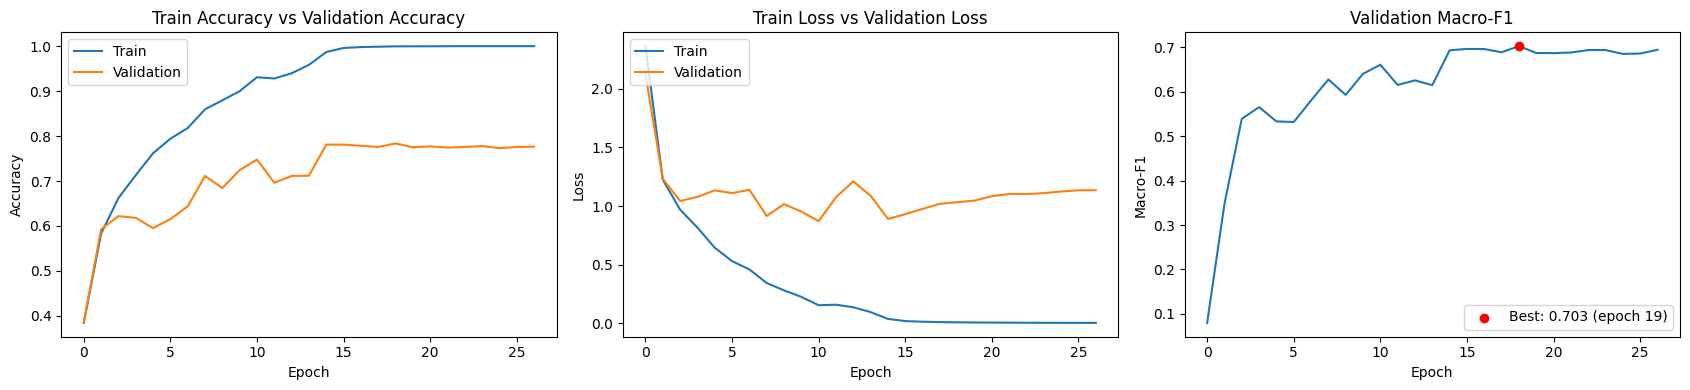

In [ ]:
# Tracé des courbes de loss, d'accuracy et macro-f1

fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Train Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Train Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

f1 = history.history['val_macro_f1']
best = int(np.argmax(f1))
ax[2].plot(f1)
ax[2].scatter(best, f1[best], color="red", zorder=3, label=f"Best: {f1[best]:.3f} (epoch {best + 1})")
ax[2].set_title('Validation Macro-F1')
ax[2].set_ylabel('Macro-F1')
ax[2].set_xlabel('Epoch')
ax[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

### (Optionel) charger le modèle CNN pré-entraîné (fourni dans le dépôt Git)
Pour éviter de devoir réentraîner exécutant la cellule d'entraînement, exécuter cette cellule :

In [ ]:
model = keras.models.load_model("models/cnn_model_base.keras")

# Partie 5 - Évaluation et analyse des erreurs

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


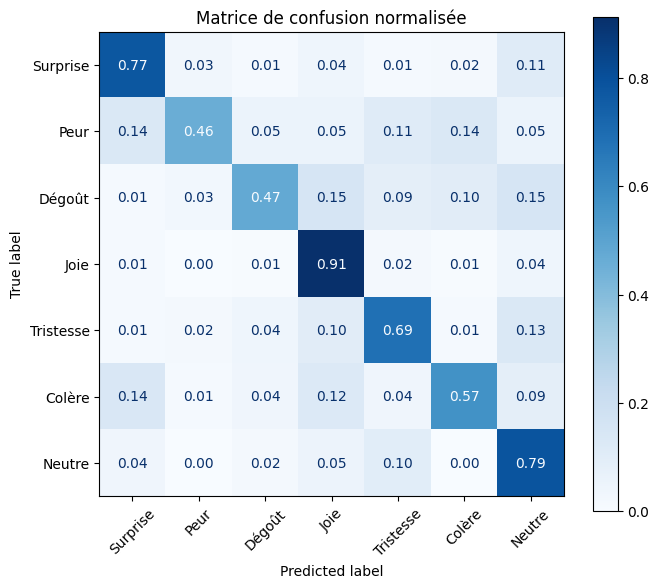

              precision    recall  f1-score   support

    Surprise      0.756     0.774     0.765       164
        Peur      0.567     0.459     0.507        37
      Dégoût      0.576     0.475     0.521        80
        Joie      0.881     0.912     0.896       593
   Tristesse      0.729     0.686     0.707       239
      Colère      0.657     0.568     0.609        81
      Neutre      0.740     0.785     0.762       340

    accuracy                          0.782      1534
   macro avg      0.701     0.666     0.681      1534
weighted avg      0.777     0.782     0.779      1534



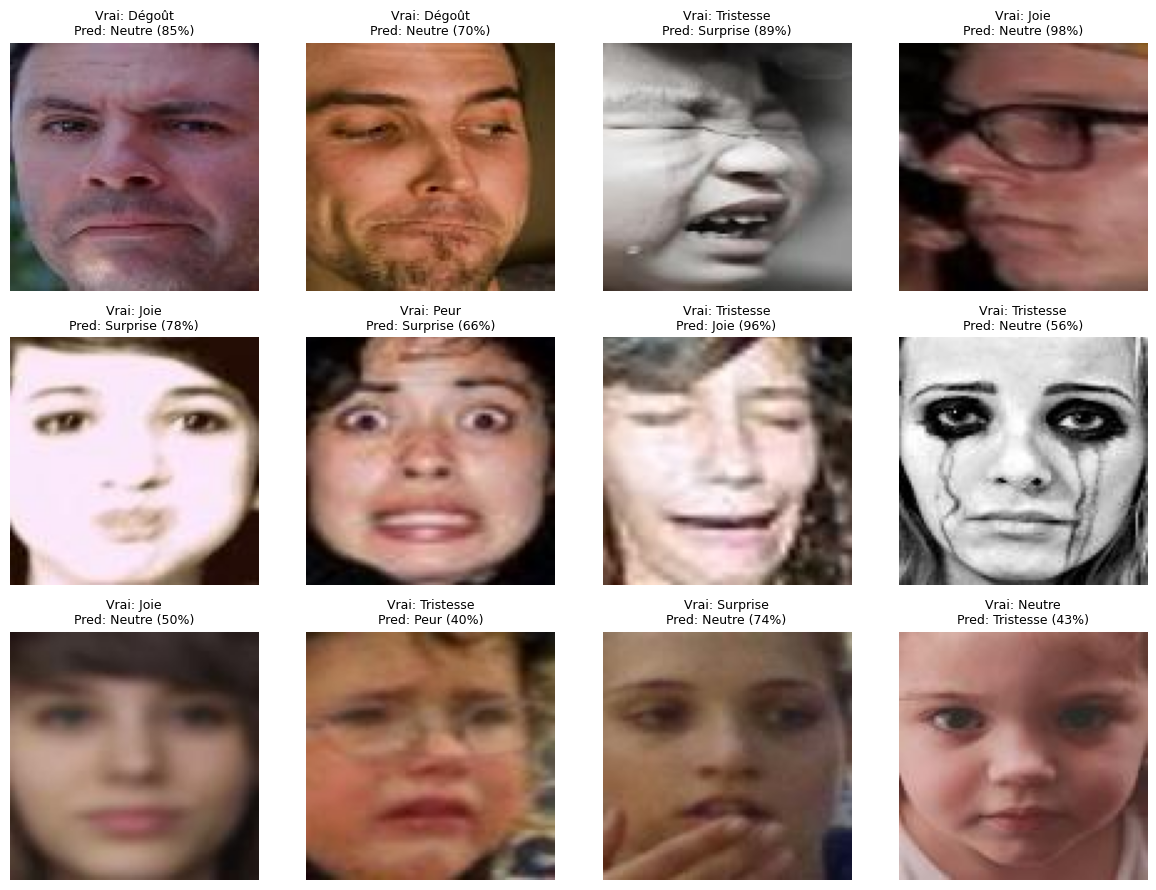

In [ ]:
# Predictions sur le set de test (test_dataset pas mélangé, donc l'ordre correspond à df_test)
probs = model.predict(test_dataset)
y_pred = probs.argmax(axis=1)
y_true = df_test["label"].values

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=emotions).plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f")
plt.title("Matrice de confusion normalisée")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=emotions, digits=3))

# Exemples de mauvaises prédictions
wrong = np.where(y_pred != y_true)[0]
rng = np.random.default_rng(SEED)
picks = rng.choice(wrong, size=min(12, len(wrong)), replace=False)

plt.figure(figsize=(12, 9))
for i, idx in enumerate(picks):
    plt.subplot(3, 4, i + 1)
    plt.imshow(Image.open(df_test.iloc[idx]["image_path"]))
    plt.title(f"Vrai: {emotions[y_true[idx]]}\nPred: {emotions[y_pred[idx]]} ({probs[idx, y_pred[idx]]:.0%})", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

La matrice de confusion affiche le recall de chaque classe réelle dans les cases. Les lignes représentent les vraies classes et tes colonnes les classes prédites.


Les expressions les mieux identifiées sont la Joie, la Surprise et Neutre.

Les expressions sont globalement bien reconnues mais deux classes ont un faible recall par rapport au reste : la Peur est souvent confondue avec la Surprise ou la Colère. De même, le Dégoût est souvent confondu avec Neutre, la Joie, ou la Tristesse/Colère.

Cela peut s'expliquer par plusieurs raisons :
1. **Ressemblance des expressions et subjectivité des vrais labels :** Certaines expressions faciales peuvent se ressembler comme la peur et la surprise par exemple. En regardant les exemples de prédictions incorrectes, même un humain peut effectivement avoir du mal à identifier certaines expressions de par la mauvaise qualité des images ou simplement l'interprétation.

En prenant ces exemples ci-dessous :
<img src="https://i.imgur.com/eno1Sjg.png">
L'image à la deuxième ligne tout à droite où le visage semble globalement neutre mais sourit légèrement, d'où la mauvaise prédiction de Joie à une probabilité de 64%. Un autre exemple peut être la troisième image en partant de la gauche, sur la dernière ligne, prédite Neutre à 67% mais la vraie classe est "Joie", alors que l'expression a peu d'indications pour justifier cette étiquette (sourire très peu marqué).

2. **Déséquilibre des classes :**  On retrouve cette tendance en regardant les F1-scores : les classes disposant de davantage d'exemples ont souvent de meilleures performances. La joie possède beaucoup plus d'exemples que les autres classes, donc le CNN voit beaucoup plus souvent des visages joyeux pendant l'entraînement. Il apprend alors généralement des représentations plus robustes pour cette classe. À l'inverse, la Peur, le Dégoût et la Colère sont les classes minoritaires : il y a moins d'exemples permettant au réseau d'apprendre ses caractéristiques spécifiques. Lorsqu'une image est ambiguë, le réseau peut alors avoir tendance à privilégier la classe qu'il connaît le mieux, ce pourquoi la Joie est souvent proposée pour ces classes qui ont plus de mal à être apprises. Cependant, le nombre d'exemples n'explique probablement pas à lui seul les performances. En effet, la Colère, qui a un effectif légèremment plus bas que le Dégoût, est pourtant moins confondue que le Dégoût. Cela s'explique sans doute car l'expression faciale de cette émotion est par nature plus prononcée/plus identifiable/moins ambigüe.

3. **Surapprentissage des classes peu représentées :** lié au déséquilibre des classes, le réseau a beaucoup plus de diversité dans les exemples pour apprendre les classes qui ont un grand effectif (personnes différentes, âges différents, intensités des expressions faciales, éclairages différents, tailles de visage différentes...), alors que pour la Peur, le réseau a beaucoup moins d'exemples. Il risque donc davantage de sur-apprendre les quelques exemples disponibles plutôt que d'apprendre une représentation générale de la classe.

Nous avions pourtant mis des `class_weight` pour prendre en compte le déséquilibre des classes pour que le réseau soit entraîné en donnant davantage de poids aux erreurs commises sur les classes minoritaires : une classe rare reçoit ainsi un poids plus important. Cependant, cela mitigue seulement le problème du déséquilibre des classes : les erreurs sur la peur par exemple coûtent davantage à la fonction perte, mais le problème de quantité et de diversité des données est toujours présent. Ainsi, une classe rare peut toujours être moins bien apprise parce qu'elle offre moins de variations permettant au CNN d'apprendre une représentation robuste.

# Partie 6 - Expérimentation et amélioration

Nous allons à présent réaliser 3 expériences pour essayer d'analyser plus en profondeur notre modèle, et potentiellement l'améliorer.
Ces expériences reprendront donc le même code que pour le modèle original afin d'avoir une comparaison possible

### (Optionnel) charger les modèles pré-entraînés des 3 expériences (fournis dans le dépôt Git)
Pour éviter de devoir réentraîner exécutant la cellule d'entraînement, exécuter cette cellule :

In [ ]:
model_exp_1 = keras.models.load_model("models/cnn_exp_1.keras")
model_exp_2 = keras.models.load_model("models/cnn_exp_2.keras")
model_exp_3 = keras.models.load_model("models/cnn_exp_3.keras")

## Expérience 1 : un autre type de pooling

> Nous allons ici reprendre le modèle mais changer de type de pooling, passant de `MaxPooling2D` à `AveragePooling2D`

In [ ]:
model_exp_1 = Sequential()

model_exp_1.add(Conv2D(32, kernel_size=(3,3), padding="same", use_bias=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_exp_1.add(BatchNormalization())
model_exp_1.add(Activation("relu"))
model_exp_1.add(AveragePooling2D(pool_size=(2,2))) # On passe à du AveragePooling

model_exp_1.add(Conv2D(64, kernel_size=(3,3), padding="same", use_bias=False))
model_exp_1.add(BatchNormalization())
model_exp_1.add(Activation("relu"))
model_exp_1.add(AveragePooling2D(pool_size=(2,2))) # On passe à du AveragePooling

model_exp_1.add(Conv2D(128, kernel_size=(3,3), padding="same", use_bias=False))
model_exp_1.add(BatchNormalization())
model_exp_1.add(Activation("relu"))
model_exp_1.add(AveragePooling2D(pool_size=(2,2))) # On passe à du AveragePooling

model_exp_1.add(Flatten())
model_exp_1.add(Dense(7, activation="softmax"))

model_exp_1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 100, 100, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 50, 50, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 50, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 25, 25, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 12, 12, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │       129,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,951 (870.90 KB)

 Trainable params: 222,503 (869.15 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.3821 - loss: 2.1084 - val_accuracy: 0.4785 - val_loss: 1.6250 - val_macro_f1: 0.1906 - learning_rate: 0.0010
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.5599 - loss: 1.3395 - val_accuracy: 0.5541 - val_loss: 1.2167 - val_macro_f1: 0.4463 - learning_rate: 0.0010
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6386 - loss: 1.0725 - val_accuracy: 0.5978 - val_loss: 1.0608 - val_macro_f1: 0.4896 - learning_rate: 0.0010
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6862 - loss: 0.9151 - val_accuracy: 0.6584 - val_loss: 0.9683 - val_macro_f1: 0.5543 - learning_rate: 0.0010
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7347 - loss: 0.7380 - val_accuracy: 0.5430 - val_loss: 1.2692 - val_macro_f1: 0.4841 - learning_rate: 0.0010
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7612 - loss: 0.6330 - val_accuracy: 0.6297 - val_lo

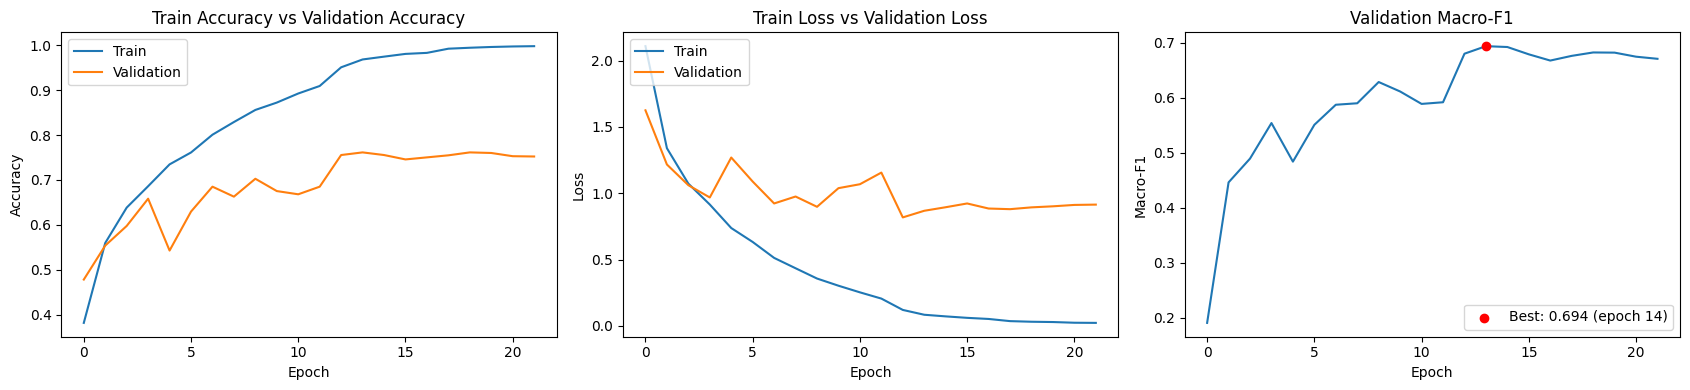

In [ ]:
model_exp_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # les labels sont des entiers de 0 à 6, pas one-hot enconding donc sparse
    metrics=["accuracy"],
)

classes = np.arange(7)
w = compute_class_weight("balanced", classes=classes, y=df_train["label"].values)
class_weight = dict(zip(classes, w))

class MacroF1(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, y_pred, average="macro")


EPOCHS = 30
callbacks = [
    MacroF1(val_dataset, df_val["label"].values), # important à laisser en premier pour que val_macro_f1 soit déjà dans les logs quand ReduceLrOnPlateau et Early stopping le lisent
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
]

history = model_exp_1.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,class_weight=class_weight, callbacks=callbacks)

# Tracé des courbes de loss, d'accuracy et macro-f1
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Train Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Train Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

f1 = history.history['val_macro_f1']
best = int(np.argmax(f1))
ax[2].plot(f1)
ax[2].scatter(best, f1[best], color="red", zorder=3, label=f"Best: {f1[best]:.3f} (epoch {best + 1})")
ax[2].set_title('Validation Macro-F1')
ax[2].set_ylabel('Macro-F1')
ax[2].set_xlabel('Epoch')
ax[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

Conclusion : Aucune performance notable n'a été apporté

## Expérience 2 : Changer la taille du filtre

In [ ]:
model_exp_2 = Sequential()

model_exp_2.add(Conv2D(32, kernel_size=(3,3), padding="same", use_bias=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_exp_2.add(BatchNormalization())
model_exp_2.add(Activation("relu"))
model_exp_2.add(MaxPooling2D(pool_size=(4,4))) # On change la taille du filtre de (2x2) à (4x4)

model_exp_2.add(Conv2D(64, kernel_size=(3,3), padding="same", use_bias=False))
model_exp_2.add(BatchNormalization())
model_exp_2.add(Activation("relu"))
model_exp_2.add(MaxPooling2D(pool_size=(4,4))) # On change la taille du filtre de (2x2) à (4x4)

model_exp_2.add(Conv2D(128, kernel_size=(3,3), padding="same", use_bias=False))
model_exp_2.add(BatchNormalization())
model_exp_2.add(Activation("relu"))
model_exp_2.add(MaxPooling2D(pool_size=(4,4))) # On change la taille du filtre de (2x2) à (4x4)

model_exp_2.add(Flatten())
model_exp_2.add(Dense(7, activation="softmax"))

model_exp_2.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 25, 25, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 6, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,823 (370.40 KB)

 Trainable params: 94,375 (368.65 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.3389 - loss: 1.7539 - val_accuracy: 0.3253 - val_loss: 1.7397 - val_macro_f1: 0.1387 - learning_rate: 0.0010
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5023 - loss: 1.3841 - val_accuracy: 0.5052 - val_loss: 1.4700 - val_macro_f1: 0.3950 - learning_rate: 0.0010
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5746 - loss: 1.2081 - val_accuracy: 0.5228 - val_loss: 1.3228 - val_macro_f1: 0.4227 - learning_rate: 0.0010
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6246 - loss: 1.0568 - val_accuracy: 0.5502 - val_loss: 1.2934 - val_macro_f1: 0.4835 - learning_rate: 0.0010
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6679 - loss: 0.9356 - val_accuracy: 0.5313 - val_loss: 1.4058 - val_macro_f1: 0.4900 - learning_rate: 0.0010
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6935 - loss: 0.8480 - val_accuracy: 0.5587 - val_los

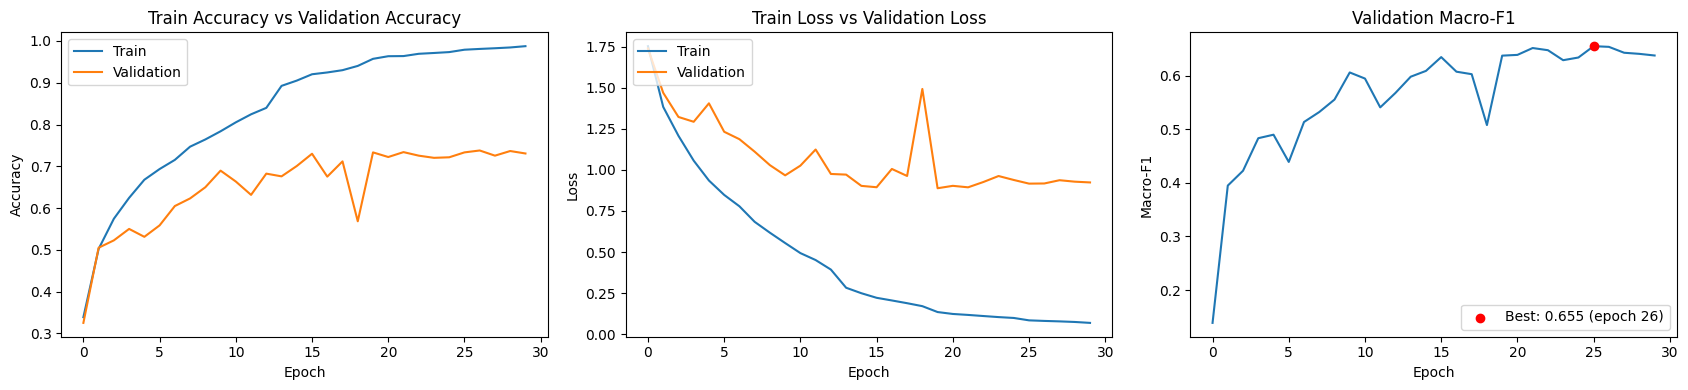

In [ ]:
model_exp_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # les labels sont des entiers de 0 à 6, pas one-hot enconding donc sparse
    metrics=["accuracy"],
)

classes = np.arange(7)
w = compute_class_weight("balanced", classes=classes, y=df_train["label"].values)
class_weight = dict(zip(classes, w))

class MacroF1(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, y_pred, average="macro")


EPOCHS = 30
callbacks = [
    MacroF1(val_dataset, df_val["label"].values), # important à laisser en premier pour que val_macro_f1 soit déjà dans les logs quand ReduceLrOnPlateau et Early stopping le lisent
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
]

history = model_exp_2.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,class_weight=class_weight, callbacks=callbacks)

# Tracé des courbes de loss, d'accuracy et macro-f1
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Train Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Train Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

f1 = history.history['val_macro_f1']
best = int(np.argmax(f1))
ax[2].plot(f1)
ax[2].scatter(best, f1[best], color="red", zorder=3, label=f"Best: {f1[best]:.3f} (epoch {best + 1})")
ax[2].set_title('Validation Macro-F1')
ax[2].set_ylabel('Macro-F1')
ax[2].set_xlabel('Epoch')
ax[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Expérience 3 : Rajout de couche Dropout

> Pour qu'un Dropout soit le plus efficace, la bonne pratique consiste à ajouter une couche Dense intermédiaire avant la sortie. C'est à cet endroit que le risque de surapprentissage (overfitting) est le plus élevé, à cause du nombre important de paramètres présent

In [ ]:
model_exp_3 = Sequential()

model_exp_3.add(Conv2D(32, kernel_size=(3,3), padding="same", use_bias=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_exp_3.add(BatchNormalization())
model_exp_3.add(Activation("relu"))
model_exp_3.add(MaxPooling2D(pool_size=(2,2)))

model_exp_3.add(Conv2D(64, kernel_size=(3,3), padding="same", use_bias=False))
model_exp_3.add(BatchNormalization())
model_exp_3.add(Activation("relu"))
model_exp_3.add(MaxPooling2D(pool_size=(2,2)))

model_exp_3.add(Conv2D(128, kernel_size=(3,3), padding="same", use_bias=False))
model_exp_3.add(BatchNormalization())
model_exp_3.add(Activation("relu"))
model_exp_3.add(MaxPooling2D(pool_size=(2,2)))

model_exp_3.add(Dense(256, activation="relu"))  # Couche dense intermédiaire
model_exp_3.add(BatchNormalization())           # Optionnel, mais souvent utile
model_exp_3.add(Dropout(0.5))                   # Nouvelle couche Dropout, avec une probabilité de 0.5

model_exp_3.add(Flatten())
model_exp_3.add(Dense(7, activation="softmax"))

model_exp_3.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 100, 100, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 25, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 12, 12, 256)    │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │       258,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,023 (1.47 MB)

 Trainable params: 385,063 (1.47 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.3900 - loss: 3.8341 - val_accuracy: 0.2158 - val_loss: 3.6119 - val_macro_f1: 0.0880 - learning_rate: 0.0010
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5047 - loss: 2.7694 - val_accuracy: 0.4309 - val_loss: 1.8075 - val_macro_f1: 0.3462 - learning_rate: 0.0010
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.5624 - loss: 2.3337 - val_accuracy: 0.4804 - val_loss: 2.0718 - val_macro_f1: 0.4352 - learning_rate: 0.0010
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6012 - loss: 1.8975 - val_accuracy: 0.5013 - val_loss: 2.2632 - val_macro_f1: 0.4326 - learning_rate: 0.0010
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6577 - loss: 1.4344 - val_accuracy: 0.5639 - val_loss: 1.9835 - val_macro_f1: 0.4837 - learning_rate: 0.0010
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6871 - loss: 1.2234 - val_accuracy: 0.5919 - val_los

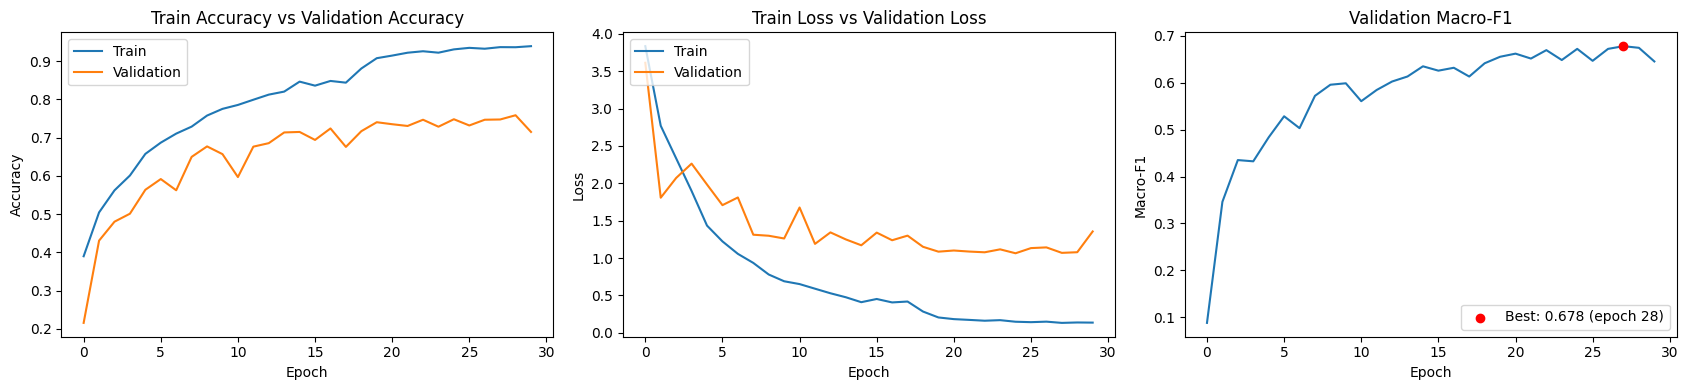

In [ ]:
model_exp_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # les labels sont des entiers de 0 à 6, pas one-hot enconding donc sparse
    metrics=["accuracy"],
)

classes = np.arange(7)
w = compute_class_weight("balanced", classes=classes, y=df_train["label"].values)
class_weight = dict(zip(classes, w))

class MacroF1(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, y_pred, average="macro")


EPOCHS = 30
callbacks = [
    MacroF1(val_dataset, df_val["label"].values), # important à laisser en premier pour que val_macro_f1 soit déjà dans les logs quand ReduceLrOnPlateau et Early stopping le lisent
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
]

history = model_exp_3.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,class_weight=class_weight, callbacks=callbacks)

# Tracé des courbes de loss, d'accuracy et macro-f1
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Train Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Train Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

f1 = history.history['val_macro_f1']
best = int(np.argmax(f1))
ax[2].plot(f1)
ax[2].scatter(best, f1[best], color="red", zorder=3, label=f"Best: {f1[best]:.3f} (epoch {best + 1})")
ax[2].set_title('Validation Macro-F1')
ax[2].set_ylabel('Macro-F1')
ax[2].set_xlabel('Epoch')
ax[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Comparaison et conclusion

Tableau comparatif

| Modèle| Accuracy, Loss, Macro-F1    |
| ---------------------- | ---------------- |
| Base  | ![base.png](images/comparaisons/base.png) |
| Expérience 1 (`AveragePooling`)  | ![exp_1.png](images/comparaisons/exp_1.png) |
| Expérience 2 (filtre 4x4)  | ![exp_2.png](images/comparaisons/exp_2.png) |
| Expérience 3 (Ajout `Dropout`)  | ![exp_3.png](images/comparaisons/exp_3.png) |

> Au final, aucune de ces expériences n'a apporté de plus-value concrète au modèle. Bien que les courbes différent légérement au fil des epochs, les 3 expériences amènent à des métriques que l'on peut qualifier d'identique. On peut cependant noter que pour l'expérience où nous avons rajouté une couche Dropout, le modéle a globalement légèrement moins vite surrapris.

Le modèle retenu est alors celui de base, en se basant sur le score Macro-F1 qui reste le meilleur

# Partie 7 - Enrichissement avec les nouvelles notions du cours

Dans cette partie, nous allons tenter d'enrichir le modéle avec de nouvelles notions

Nous avons choisi de nous pencher sur la notion de "Data Augmentation"

### (Optionnel) charger le modèle pré-entraînés (fourni dans le dépôt Git)
Pour éviter de devoir réentraîner exécutant la cellule d'entraînement, exécuter cette cellule :

In [2]:
print("TensorFlow :", tf.__version__)
print("GPU disponibles :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.21.0
GPU disponibles : []


In [ ]:
model_data_augm = keras.models.load_model("models/cnn_data_augm.keras")

## Data Augmentation

On va diversifier les données vues par le modèle en ajoutant un mirroir horizontal, et en ajustant le contraste des images de manière aléatoire, en espérant que cela aide le modèle à mieux généraliser.

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),        # Retournement horizontal aléatoire
    layers.RandomContrast(0.1),             # Ajustement du contraste
], name="data_augmentation")

model_data_augm = Sequential()

model_data_augm.add(data_augmentation) # On ajoute au début du modèle

model_data_augm.add(Conv2D(32, kernel_size=(3,3), padding="same", use_bias=False, input_shape=(IMG_SIZE,IMG_SIZE,3)))
model_data_augm.add(BatchNormalization())
model_data_augm.add(Activation("relu"))
model_data_augm.add(AveragePooling2D(pool_size=(2,2))) # On passe à du AveragePooling

model_data_augm.add(Conv2D(64, kernel_size=(3,3), padding="same", use_bias=False))
model_data_augm.add(BatchNormalization())
model_data_augm.add(Activation("relu"))
model_data_augm.add(AveragePooling2D(pool_size=(2,2))) # On passe à du AveragePooling

model_data_augm.add(Conv2D(128, kernel_size=(3,3), padding="same", use_bias=False))
model_data_augm.add(BatchNormalization())
model_data_augm.add(Activation("relu"))
model_data_augm.add(AveragePooling2D(pool_size=(2,2))) # On passe à du AveragePooling

model_data_augm.add(Flatten())
model_data_augm.add(Dense(7, activation="softmax"))

model_data_augm.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_8             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.4024 - loss: 2.0855 - val_accuracy: 0.4068 - val_loss: 1.7108 - val_macro_f1: 0.1772 - learning_rate: 0.0010
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5528 - loss: 1.3898 - val_accuracy: 0.4198 - val_loss: 1.6495 - val_macro_f1: 0.3384 - learning_rate: 0.0010
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6278 - loss: 1.1393 - val_accuracy: 0.6278 - val_loss: 1.0234 - val_macro_f1: 0.5208 - learning_rate: 0.0010
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6698 - loss: 0.9738 - val_accuracy: 0.6265 - val_loss: 0.9957 - val_macro_f1: 0.5472 - learning_rate: 0.0010
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7044 - loss: 0.8670 - val_accuracy: 0.6297 - val_loss: 1.0078 - val_macro_f1: 0.5361 - learning_rate: 0.0010
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7307 - loss: 0.7913 - val_accuracy: 0.7106 - val_los

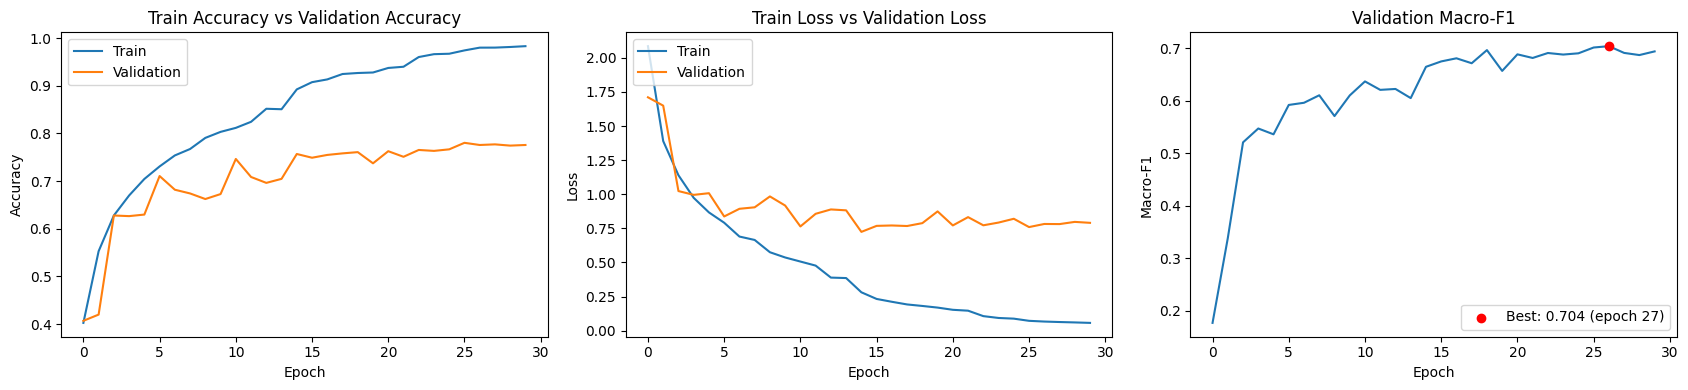

In [ ]:
model_data_augm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # les labels sont des entiers de 0 à 6, pas one-hot enconding donc sparse
    metrics=["accuracy"],
)

classes = np.arange(7)
w = compute_class_weight("balanced", classes=classes, y=df_train["label"].values)
class_weight = dict(zip(classes, w))

class MacroF1(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds, self.y_val = val_ds, y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, y_pred, average="macro")


EPOCHS = 30
callbacks = [
    MacroF1(val_dataset, df_val["label"].values), # important à laisser en premier pour que val_macro_f1 soit déjà dans les logs quand ReduceLrOnPlateau et Early stopping le lisent
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=3),
    EarlyStopping(monitor="val_macro_f1", mode="max", patience=8, restore_best_weights=True),
]

history = model_data_augm.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,class_weight=class_weight, callbacks=callbacks)

# Tracé des courbes de loss, d'accuracy et macro-f1
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Train Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Train Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

f1 = history.history['val_macro_f1']
best = int(np.argmax(f1))
ax[2].plot(f1)
ax[2].scatter(best, f1[best], color="red", zorder=3, label=f"Best: {f1[best]:.3f} (epoch {best + 1})")
ax[2].set_title('Validation Macro-F1')
ax[2].set_ylabel('Macro-F1')
ax[2].set_xlabel('Epoch')
ax[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


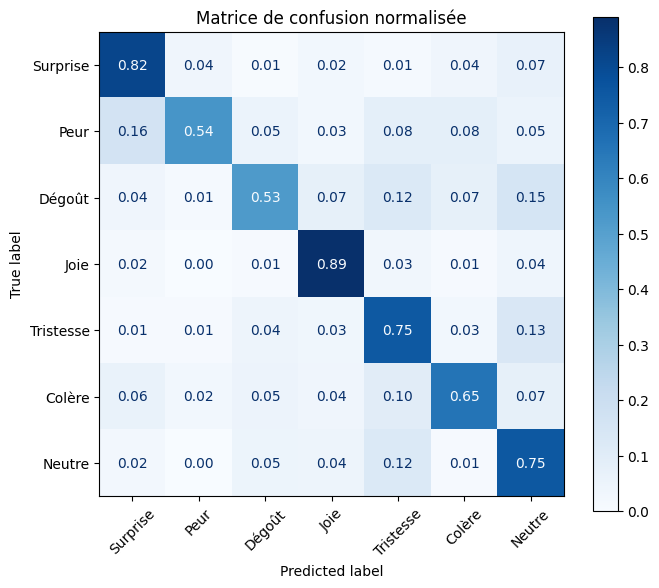

              precision    recall  f1-score   support

    Surprise      0.788     0.817     0.802       164
        Peur      0.606     0.541     0.571        37
      Dégoût      0.525     0.525     0.525        80
        Joie      0.935     0.890     0.912       593
   Tristesse      0.686     0.749     0.716       239
      Colère      0.646     0.654     0.650        81
      Neutre      0.746     0.753     0.750       340

    accuracy                          0.790      1534
   macro avg      0.705     0.704     0.704      1534
weighted avg      0.794     0.790     0.792      1534



In [ ]:
# Predictions sur le set de test (test_dataset pas mélangé, donc l'ordre correspond à df_test)
probs = model_data_augm.predict(test_dataset)
y_pred = probs.argmax(axis=1)
y_true = df_test["label"].values

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=emotions).plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f")
plt.title("Matrice de confusion normalisée")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=emotions, digits=3))

## Conclusion

> On peut noter ici que cet enrichissement a permis d'améliorer les résultats sur la loss (moins de surapprentissage), et le recall de certaines classes. On peut alors en conclure que cette expérience a bel et bien amélioré le modèle. On s'en servira donc de base pour la suite du projet.

In [ ]:
model = model_data_augm

# ou charger directement le modèle pré-entraîné :
#model = keras.models.load_model("models/cnn_data_augm.keras")

In [4]:
model = keras.models.load_model("cnn_data_augm.keras")

# Partie 8 - Extension : détection et analyse de plusieurs visages (YOLO)

## Importer un modèle pré-entraîné YOLO

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.6 MB/s eta 0:00:00


## Récupérer la sortie du modèle YOLO et extraire les visages

In [5]:
from ultralytics import YOLO
from huggingface_hub import hf_hub_download

# Récupérer le modèle sur Hugging Face
yolo_model_path = hf_hub_download(repo_id="arnabdhar/YOLOv8-Face-Detection", filename="model.pt")

# Charger le détecteur de visages YOLO
yolo_model = YOLO(yolo_model_path)

# CNN classifieur d'expressions entraîné précédemmnt
emotion_model = model

## Récupérer la sortie de YOLO et extraire les visages détectés

In [ ]:
# Fonction pour récupérer les Bounding Boxes détectée en inférence par YOLO
def detect_faces(image_path, conf=0.5):
  results = yolo_model.predict(
      source=image_path,
      conf=conf,
      device="cpu",
      verbose=False
  )

  bb_result = results[0]
  boxes = bb_result.boxes.xyxy.cpu().numpy()
  scores = bb_result.boxes.conf.cpu().numpy()
  return boxes, scores

# Fonction pour isoler les visages détecter (pour les donner au classifieur d'expression par la suite)
def crop_face(image, box):
    x1, y1, x2, y2 = box.astype(int)

    # S'assurer que les coordonnées restent dans l'image
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(image.width, x2)
    y2 = min(image.height, y2)

    return image.crop((x1, y1, x2, y2))

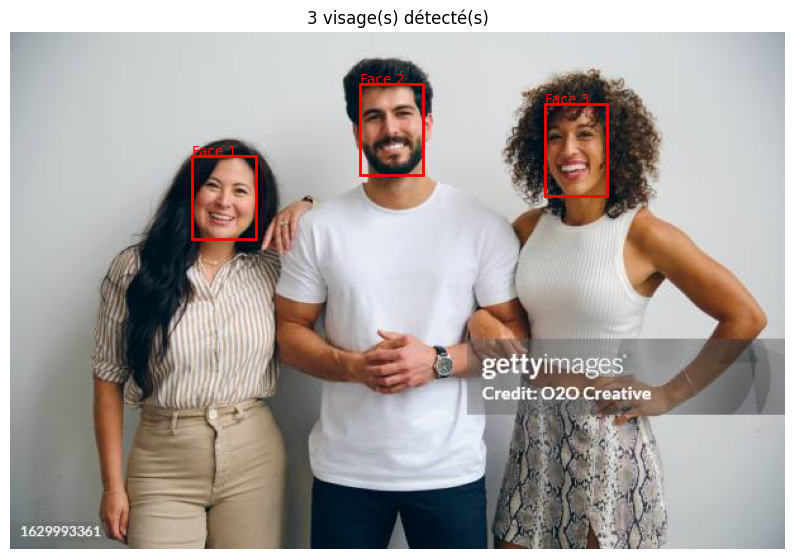

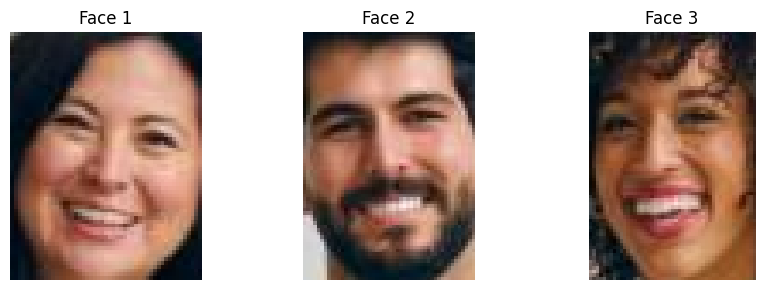

In [ ]:
# Test
img_test_path = 'sample_yolo_image.jpg'
img_test = Image.open(img_test_path).convert("RGB")

detected_boxes, detected_scores = detect_faces(img_test_path)

# Afficher les bounding boxes
plt.figure(figsize=(10, 7))
plt.imshow(img_test)
for i, box in enumerate(detected_boxes):
    x1, y1, x2, y2 = map(int, box)

    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
            edgecolor="red"
        )
    )

    plt.text(x1, y1, f"Face {i+1}", fontsize=10, color="red")

plt.axis("off")
plt.title(f"{len(detected_boxes)} visage(s) détecté(s)")
plt.show()

# Crop de chaque visage
cropped_faces = []

for box in detected_boxes:
    face = crop_face(img_test, box)
    cropped_faces.append(face)


# Afficher les visages rognés
n = len(cropped_faces)

if n == 0:
    print("Aucun visage détecté.")
else:
    fig, axes = plt.subplots(
        1, n,
        figsize=(3 * n, 3)
    )

    # Cas où il n'y a qu'un seul visage
    if n == 1:
        axes = [axes]

    for i, face in enumerate(cropped_faces):
        axes[i].imshow(face)
        axes[i].set_title(f"Face {i+1}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

## Appliquer le prétraiement nécessaire aux visages détectés par YOLO

Avant de donner les visages au classifieur CNN entraîné précédemment, on leur applique le même prétraitement que sur les images du dataset utilisées pour entraîner le CNN. Donc :
* Dimension 100 x 100 x 3 (RGB)
* Normalisation des pixels dans $[0,1]$

In [ ]:
def preprocess_face(face):
    face = face.convert("RGB") # s'assurer que l'image est bien sur 3 canaux
    face = face.resize((IMG_SIZE, IMG_SIZE)) # redimensionnement 100x100
    face = np.array(face).astype("float32")
    face /= 255.0 # normalisation
    return face

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
<class 'numpy.ndarray'>
(1, 100, 100, 3)


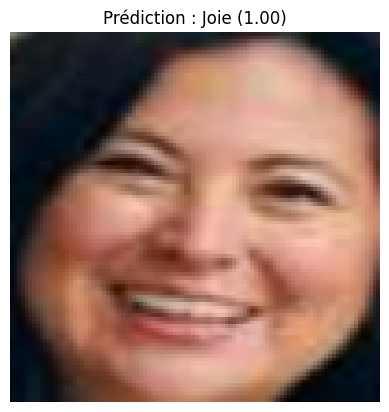

In [ ]:
# Test de preprocess d'un visage obtenu par YOLO
face_test = preprocess_face(cropped_faces[0])

# le CNN attend un batch et non une image seule
# ajouter une dimension virtuelle pour faire office de "batch"
face_test = np.expand_dims(face_test, axis=0)

# Test d'une prédiction sur ce visage
prediction_test = model.predict(face_test)
predicted_class_test = np.argmax(prediction_test)
predicted_emotion_test = emotions[predicted_class_test] # emotions est défini plus tôt
confidence_test = prediction_test[0][predicted_class_test]

# Afficher le type, les dimensions et l'exemple visuel du résultat
print(type(face_test))
print(face_test.shape)
plt.imshow(face_test[0]) # Display the first image in the batch
plt.title(f'Prédiction : {predicted_emotion_test} ({confidence_test:.2f})')
plt.axis('off')
plt.show()

## Pipeline YOLO détection de visages -> classifieur d'expression faciale CNN

In [ ]:
def detect_and_classify(image_path, conf=0.5):
    # Chargement de l'image donnée
    image = Image.open(image_path).convert("RGB")

    # Récupérer les bounding boxes et leur score
    boxes, detection_scores = detect_faces(image_path,conf=conf)

    predictions = []

    # Pour chaque bounding box (visage détecté)
    for box, detection_score in zip(boxes, detection_scores):
        face = crop_face(image, box) # extraire le visage
        face_array = preprocess_face(face) # prétraitement de l'image pour le CNN

        # le CNN attend un batch et non une image seule
        # ajouter une dimension virtuelle pour faire office de "batch"
        face_array = np.expand_dims(face_array,axis=0)

        # Classification de l'expression du visage par le CNN
        probs = emotion_model.predict(face_array,verbose=0)[0]
        pred_idx = np.argmax(probs) # predictions
        predictions.append({
            "box": box.astype(int),
            "detection_score": float(detection_score),
            "emotion": emotions[pred_idx],
            "emotion_score": float(probs[pred_idx]),
            "probabilities": probs
        })

    return image, predictions

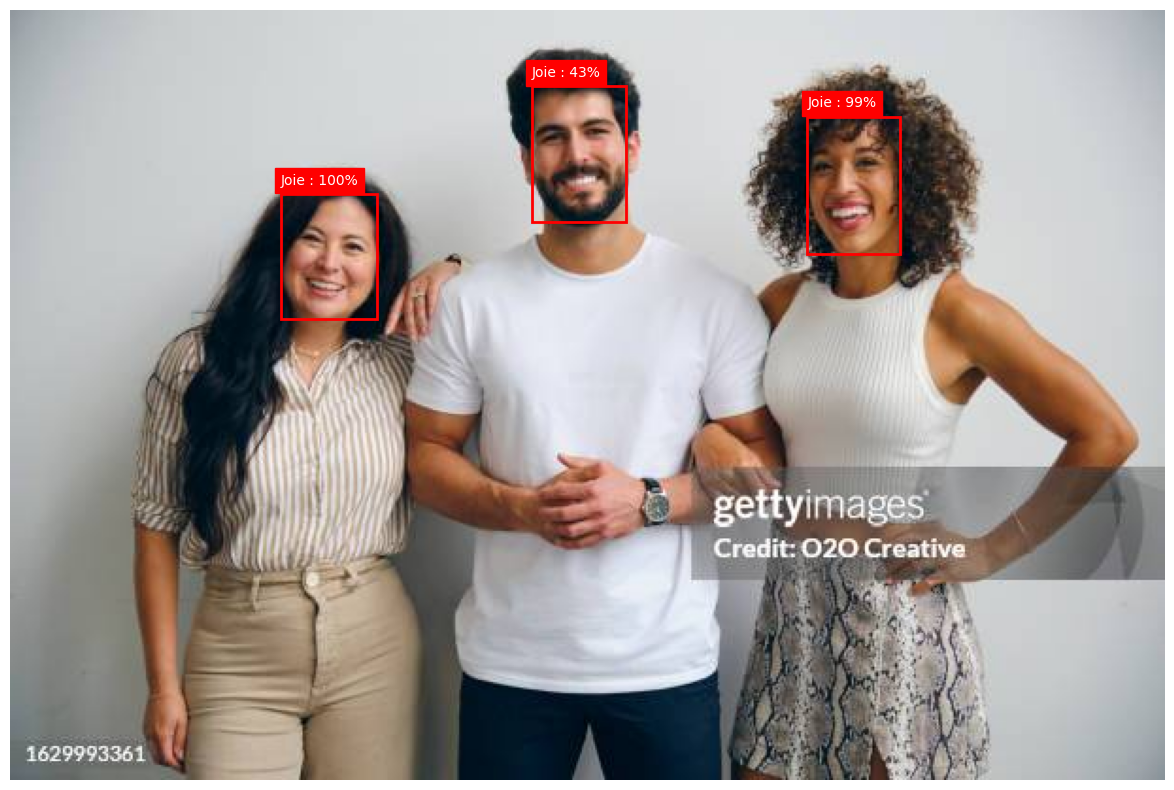

In [ ]:
# Test de la pipeline
image, predictions = detect_and_classify(img_test_path)
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image)

for pred in predictions:
    x1, y1, x2, y2 = pred["box"]
    emotion = pred["emotion"]
    emotion_score = pred["emotion_score"]
    detection_score = pred["detection_score"]

    # Bounding box
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)

    # Texte
    label = (f"{emotion} : {emotion_score:.0%}")

    ax.text(
        x1,
        max(0, y1 - 5),
        label,
        fontsize=10,
        color="white",
        backgroundcolor="red"
    )

ax.axis("off")
plt.tight_layout()
plt.show()

# Partie 9 - Extension possible à la vidéo

Dans cette partie, nous étendons le processus sur une vidéo entière.
Le processus est le suivant : `Vidéo → images successives → détection → extraction des visages → CNN → prédictions → affichage`

On prend donc en entrée une video, puis avec `ffmpeg` on découpe la vidéo en frames qu'on enregistre. Puis ces frames sont analysés, comme en partie 8 une par une puis le résultat est enregistré à son tout. À la fin, en utilisant `ffmpeg`, on construit la vidéo finale avec toutes les frames annotées.

In [ ]:
import glob

# Créations des dossiers pour stocker les images brutes et les images annotées
os.makedirs("/content/video_frames", exist_ok=True)
os.makedirs("/content/annotated_frames", exist_ok=True)

# Découper la vidéo en images avec ffmpeg (5 fps)
video_path = '/content/images/video.mp4'
!ffmpeg -i {video_path} -vf "fps=5" /content/video_frames/frame_%04d.jpg -y

# Récupérer la liste de toutes les images extraites
frame_paths = sorted(glob.glob("/content/video_frames/*.jpg"))

print("Début du traitement ...")
# Traitement frame par frame
for path in frame_paths:
    image, predictions = detect_and_classify(path)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    ax.imshow(image)

    for pred in predictions:
        x1, y1, x2, y2 = pred["box"]
        emotion = pred["emotion"]
        emotion_score = pred["emotion_score"]

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        label = f"{emotion} : {emotion_score:.0%}"
        ax.text(
            x1,
            max(0, y1 - 5),
            label,
            fontsize=10,
            color="white",
            backgroundcolor="red"
        )

    ax.axis("off")
    plt.tight_layout()

    # Sauvegarde de la frame annotée
    out_path = path.replace("video_frames", "annotated_frames")
    plt.savefig(out_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig) # Fermer la figure pour libérer la mémoire RAM de Colab

print("Toutes les frames ont été annotées avec succès.")

# Recomposer la vidéo à partir des images annotées
output_video_path = "/content/video_resultat.mp4"
!ffmpeg -framerate 5 -i /content/annotated_frames/frame_%04d.jpg -c:v libx264 -pix_fmt yuv420p {output_video_path} -y

print(f"Vidéo finale enregistrée sous : {output_video_path}")

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena